In [1]:
# Import necessary packages
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time

# Prepare data loader
from torch.utils.data import Dataset, DataLoader
import h5py
from sklearn.metrics import accuracy_score

In [2]:
# Make sure that CUDA is available - without cuda we would be attempting to run the model on CPU which is tooooo slow. 
assert torch.cuda.is_available(), 'Cuda not available'
gpu = 'cuda'

# Parameter
### Dataset path

In [3]:
# Check if dataset is present
import os.path
# dataset_path = "datasets/MatGenData.h5"
# dataset_path = "datasets/MatGenData_0PPM.h5"
dataset_path = "datasets/new_normalized/MatGenData_ppm20_rician_20250828.h5"
os.path.isfile(dataset_path)

True

### Dataset property parameters

In [4]:
from experimental.dataset_tools import radioml_dataset
from experimental.dataset_tools import full_linear_scale_quantizer, simple_linear_scale_quantizer, base_dataset_quantizer, standard_int8_norm
# data_key='all_IQ_int8'
data_key='all_IQ_float32'
mod_key='all_labels'
snr_key='all_SNRs'
snr_lower_bound=0.0
snr_upper_bound=30.0
snr_steps=2.0

mod_classes = ["BPSK", 
                "QPSK", 
                "8PSK",
                "16QAM",
                "32QAM", 
                "64QAM", 
                "128QAM", 
                "256QAM",
                "16APSK", 
                "32APSK", 
                "64APSK", 
                "128APSK",
                "FM", 
                "AM-DSB-SC", 
                "AM-SSB-SC"]

snr_classes = np.arange(snr_lower_bound,
                        snr_upper_bound+1.0,
                        snr_steps) 

quantization_dtype=np.int8
quantizer=standard_int8_norm(-3.2, 3.2, np.int8)
build_dir='mat_gen_vanilla_10112025' #directory to save model
model_file_name='model_vanilla.pth' #name of the pth file
Path(build_dir).mkdir(exist_ok=True)
chpt_path=build_dir+'/'+model_file_name
print(f'Model parameters will be saved in {chpt_path}')

Model parameters will be saved in mat_gen_vanilla_10112025/model_vanilla.pth


## Create dataset object

In [5]:
# quantizer=simple_linear_scale_quantizer(5.5, 128, np.int8)
dataset = radioml_dataset(dataset_path=dataset_path,
                          data_key=data_key, mod_key=mod_key, snr_key=snr_key,
                          mod_classes=mod_classes,snr_classes=snr_classes,
                          dataset_quantizer=quantizer,
                          frame_per_mod_snr_combination=4096) 

debug_quantized_dataset=quantizer.quantize(dataset.data[:])

print('Raw value range: (',np.min(dataset.data),' ; ',np.max(dataset.data),')  ',dataset.data.dtype) 
print('Quantized value range: (',np.min(debug_quantized_dataset),' ; ',np.max(debug_quantized_dataset),')  ',debug_quantized_dataset.dtype) 
print('Total mods: ', len(dataset.mod_classes))
print('Number of SNRs: ',len(dataset.snr_classes))
print('Number of frames per each SNR-Modulation combination: ',
      dataset.data.shape[0]/(len(dataset.mod_classes)*len(dataset.snr_classes)))
print('SNRs: ',dataset.snr_classes,' \n')
print('Total size: ', dataset.data.shape)
print('Training set size: ',len(dataset.train_sampler))
print('Val set size: ',len(dataset.val_sampler))
print('Test set size: ',len(dataset.test_sampler))

All available keys: ['all_IQ_float32', 'all_IQ_int8', 'all_SNRs', 'all_labels']
Extracting data key all_IQ_float32
Get labels
Get SNR
Raw value range: ( -5.2298303  ;  5.397292 )   float32
Quantized value range: ( -128  ;  127 )   int8
Total mods:  15
Number of SNRs:  16
Number of frames per each SNR-Modulation combination:  4096.0
SNRs:  [ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30.]  

Total size:  (983040, 1024, 2)
Training set size:  786480
Val set size:  98400
Test set size:  98160


# Some visualizations of Dataset

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

raw_sample = dataset.data[:]  #Get the data as (1,2,1024)
# Flatten the array to 1D
raw_flattened = raw_sample.flatten()  
quantized_flatten = debug_quantized_dataset.flatten()  

## Histogram plotting values vs their frequencies

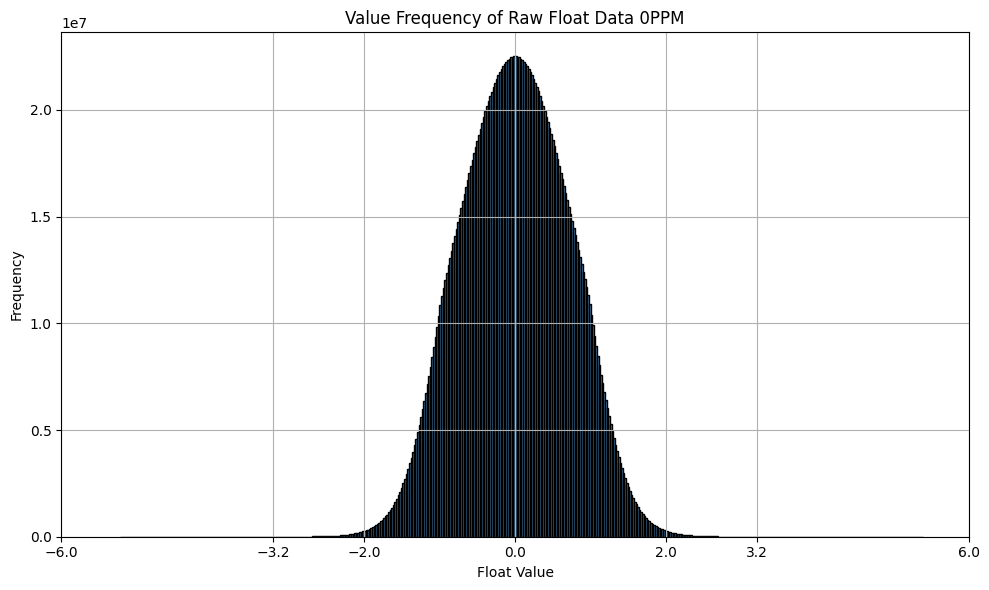

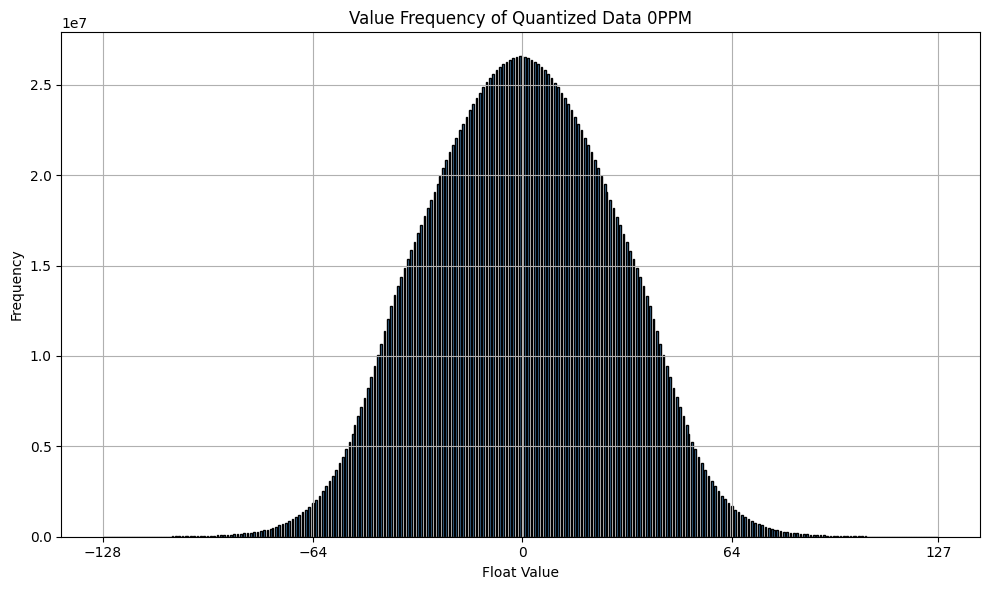

In [7]:
# Plot raw dataset histogram
plt.figure(figsize=(10, 6))
plt.hist(raw_flattened, bins=500, color='steelblue', edgecolor='black', density=False)
plt.title('Value Frequency of Raw Float Data 0PPM')
plt.xticks([-6,-3.2,-2,0,2,3.2,6])
plt.xlabel('Float Value')
plt.ylabel('Frequency')

plt.grid(True)
plt.tight_layout()
plt.show()

# Plot quantized dataset histogram
plt.figure(figsize=(10, 6))
plt.hist(quantized_flatten, bins=500, color='steelblue', edgecolor='black', density=False)
plt.title('Value Frequency of Quantized Data 0PPM')
# plt.xlim(-128, 127)
plt.xticks([-128,-64,0,64,127])
plt.xlabel('Float Value')
plt.ylabel('Frequency')

plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
quantized_dataset_name="MatGenData_ppm20_rician_int8_20250828.h5"
dataset.save_as_h5(output_path = build_dir+"/"+quantized_dataset_name,
                   data_key = 'all_IQ_8bit', 
                   mod_key = 'all_labels', 
                   snr_key = 'all_SNRs',
                   apply_quantization = True)

Saving dataset to mat_gen_vanilla_10112025/MatGenData_ppm20_rician_int8_20250828.h5
Applying quantization...
Creating dataset key 'all_IQ_8bit' with shape (983040, 1024, 2)
Creating dataset key 'all_labels' with shape (983040, 1)
Creating dataset key 'all_SNRs' with shape (983040, 1)
Dataset saved successfully to mat_gen_vanilla_10112025/MatGenData_ppm20_rician_int8_20250828.h5


## Model Parameter

In [9]:
from torch import nn

# Adjustable hyperparameters
filters_conv = 64
filters_dense = 128

# Setting seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

class VGG10(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv1d(2, filters_conv, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(filters_conv)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        
        # Conv block 2
        self.conv2 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(filters_conv)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        
        # Conv block 3
        self.conv3 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(filters_conv)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)
        
        # Conv block 4
        self.conv4 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn4 = nn.BatchNorm1d(filters_conv)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool1d(2)
        
        # Conv block 5
        self.conv5 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn5 = nn.BatchNorm1d(filters_conv)
        self.relu5 = nn.ReLU()
        self.pool5 = nn.MaxPool1d(2)
        
        # Conv block 6
        self.conv6 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn6 = nn.BatchNorm1d(filters_conv)
        self.relu6 = nn.ReLU()
        self.pool6 = nn.MaxPool1d(2)
        
        # Conv block 7
        self.conv7 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
        self.bn7 = nn.BatchNorm1d(filters_conv)
        self.relu7 = nn.ReLU()
        self.pool7 = nn.MaxPool1d(2)
        
        self.flatten = nn.Flatten()
        
        # Dense block 1
        self.fc1 = nn.Linear(filters_conv*8, filters_dense)
        self.bn8 = nn.BatchNorm1d(filters_dense)
        self.relu8 = nn.ReLU()
        
        # Dense block 2
        self.fc2 = nn.Linear(filters_dense, filters_dense)
        self.bn9 = nn.BatchNorm1d(filters_dense)
        self.relu9 = nn.ReLU()
        
        # Output layer
        self.fc3 = nn.Linear(filters_dense, 15, bias=True)

    def forward(self, x):
        # Conv blocks
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
        x = self.pool5(self.relu5(self.bn5(self.conv5(x))))
        x = self.pool6(self.relu6(self.bn6(self.conv6(x))))
        x = self.pool7(self.relu7(self.bn7(self.conv7(x))))
        
        x = self.flatten(x)
        
        # Dense blocks
        x = self.relu8(self.bn8(self.fc1(x)))
        x = self.relu9(self.bn9(self.fc2(x)))
        x = self.fc3(x)
        
        return x

model_class = VGG10()
model = model_class

import torchinfo
print(torchinfo.summary(model_class,input_size=(1,2,1024)))

Layer (type:depth-idx)                   Output Shape              Param #
VGG10                                    [1, 15]                   --
├─Conv1d: 1-1                            [1, 64, 1024]             448
├─BatchNorm1d: 1-2                       [1, 64, 1024]             128
├─ReLU: 1-3                              [1, 64, 1024]             --
├─MaxPool1d: 1-4                         [1, 64, 512]              --
├─Conv1d: 1-5                            [1, 64, 512]              12,352
├─BatchNorm1d: 1-6                       [1, 64, 512]              128
├─ReLU: 1-7                              [1, 64, 512]              --
├─MaxPool1d: 1-8                         [1, 64, 256]              --
├─Conv1d: 1-9                            [1, 64, 256]              12,352
├─BatchNorm1d: 1-10                      [1, 64, 256]              128
├─ReLU: 1-11                             [1, 64, 256]              --
├─MaxPool1d: 1-12                        [1, 64, 128]              --
├─C

# 1.4 Train and Test Functions
In the below cell we define the train, test functions, and plot loss functions. It is assumed you have some machine learning background and have a general idea of the process. 

For training, we define the following hyperparameters:
1. **num_epochs** (default=100) which is the number of iterations to train the model for
2. **batch_size** (default=1024) number of sample traces to give to the model each time it predicts
3. **Loss function** is Cross entropy loss
4. **Learning Rate** is 0.01

In [10]:
def train(model, train_loader, optimizer, criterion):
    losses = []
    # ensure model is in training mode
    model.train()    

    for (inputs, target, snr) in tqdm(train_loader, desc="Training Batches", leave=False):   
        #Converting inputs to float because for some reason torch read inputs as char type
        inputs = inputs.to(gpu).float() 
        target = target.to(gpu)
        
        # forward pass
        output = model(inputs)
        loss = criterion(output, target)
        
        # backward pass + run optimizer to update weights
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()
        
        # keep track of loss value
        losses.append(loss.cpu().detach().numpy())
           
    return losses

def test(model, test_loader):    
    # ensure model is in eval mode
    model.eval() 
    y_true = []
    y_pred = []
   
    with torch.no_grad():
        for (inputs, target, snr) in tqdm(test_loader, desc="Testing Batches", leave=False):
            inputs = inputs.to(gpu).float()
            target = target.to(gpu)
            output = model(inputs)
            pred = output.argmax(dim=1, keepdim=True)
            y_true.extend(target.tolist()) 
            y_pred.extend(pred.reshape(-1).tolist())
        
    return accuracy_score(y_true, y_pred)

def display_loss_plot(losses, title="Training loss", xlabel="Iterations", ylabel="Loss"):
    x_axis = [i for i in range(len(losses))]
    plt.plot(x_axis,losses)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


# HYPER PARAMETERS:
batch_size = 1024
num_epochs = 100
early_stop=10
minimum_epochs=50
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(gpu)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1)

In [11]:
# Set up the dataloaders
data_loader_train = DataLoader(dataset, batch_size=batch_size, sampler=dataset.train_sampler)
data_loader_val = DataLoader(dataset, batch_size=batch_size, sampler=dataset.val_sampler)
data_loader_test = DataLoader(dataset, batch_size=batch_size, sampler=dataset.test_sampler)

#if gpu is not None:
model = model.to(gpu)

### 1.4 Training Loop
The below cell is our training loop. In this cell we (1) Create the dataloaders (2) Train for either 100 epochs but stop if the validation accuracy does not improves for 10 epochs in a row. 

In [12]:
running_loss = []
running_test_acc = []
training_time=time.time()
stop_count = 0
best_acc = float('-inf')
for epoch in tqdm(range(num_epochs), desc="Epochs"):
        loss_epoch = train(model, data_loader_train, optimizer, criterion)
        val_acc = test(model, data_loader_val)
        print(f"Epoch {epoch}: Training loss = {np.mean(loss_epoch)}, validation accuracy = {val_acc}")
        if val_acc > best_acc: 
            torch.save(model.state_dict(), chpt_path)
            best_acc = val_acc
            print(f'Model checkpoint is saved in {chpt_path}')
            stop_count = 0
        else:
            stop_count+=1
        running_loss.append(loss_epoch)
        running_test_acc.append(val_acc)
        lr_scheduler.step()
        if stop_count >= early_stop and epoch>=minimum_epochs:
            break
training_time=time.time()-training_time
print(f'total training time: {training_time}')

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 0: Training loss = 1.5115108489990234, validation accuracy = 0.4051930894308943
Model checkpoint is saved in mat_gen_vanilla_10112025/model_vanilla.pth


Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

...

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 49: Training loss = 1.0326993465423584, validation accuracy = 0.5538719512195122


Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 50: Training loss = 1.08976411819458, validation accuracy = 0.5483638211382114
total training time: 3193.675628900528


## Load A Different Model

In [13]:
#Load the model back again, or you can change the file to load a different model
load_path=chpt_path #Change this to a path of a different model

model=VGG10() 
model.load_state_dict(torch.load(load_path))
model.to('cuda')

VGG10(
  (conv1): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool4): MaxPool1d(ker

# 1.5 Visualizing the models performance 
Below we create 
1. Loss per epoch plot
2. Accuracy for epoch plot
3. Test on the test dataset
4. Generate a confusion matrix plot for the test dataset 
5. Generate an accuracy plot for the test dataset 

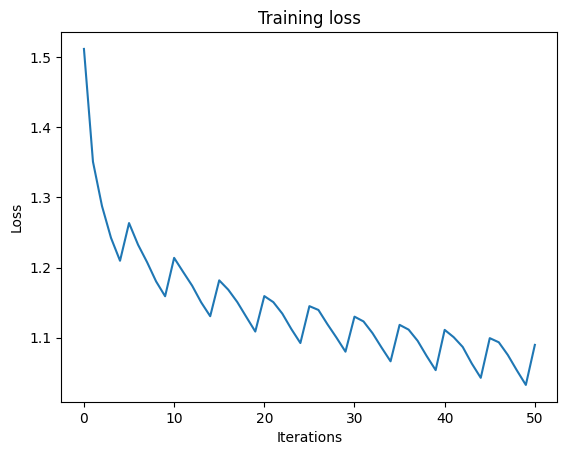

In [14]:
# Plot training loss over epochs
loss_per_epoch = [np.mean(loss_per_epoch) for loss_per_epoch in running_loss]
display_loss_plot(loss_per_epoch)

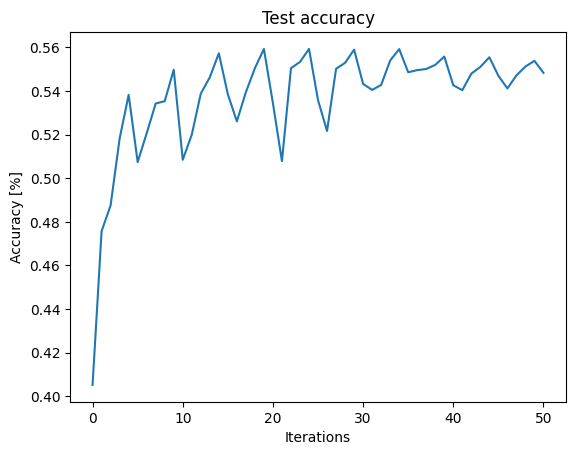

In [15]:
# Plot test accuracy over epochs
acc_per_epoch = [np.mean(acc_per_epoch) for acc_per_epoch in running_test_acc]
display_loss_plot(acc_per_epoch, title="Test accuracy", ylabel="Accuracy [%]")

# Evaluate Accuracy

In [16]:
# Run inference on validation data
y_exp = np.empty((0))
y_snr = np.empty((0))
y_pred = np.empty((0,len(dataset.mod_classes)))
model.eval()
with torch.no_grad():
    for data in tqdm(data_loader_test, desc="Batches"):
        inputs, target, snr = data
        #if gpu is not None:
        inputs = inputs.to(gpu).float()
        output = model(inputs)
        y_pred = np.concatenate((y_pred,output.cpu()))
        y_exp = np.concatenate((y_exp,target))
        y_snr = np.concatenate((y_snr,snr))

Batches:   0%|          | 0/96 [00:00<?, ?it/s]

## Confusion Matrix across all SNRs

Overall Accuracy across all SNRs: 0.558720


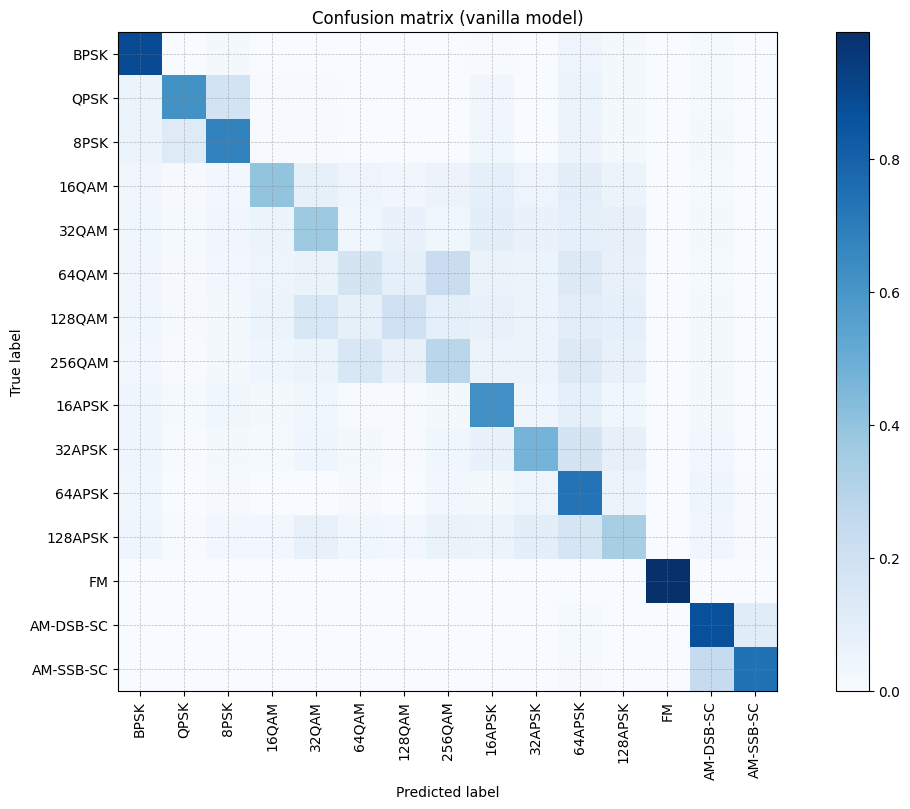

In [17]:
plot_dir=f'{build_dir}/report'
report_dir= Path(plot_dir)
report_dir.mkdir(exist_ok=True)

# Plot overall confusion matrix
def plot_confusion_matrix(cm, title='Confusion matrix (vanilla model)', cmap=plt.cm.Blues, labels=[]):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')

conf = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
confnorm = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
for i in range(len(y_exp)):
    j = int(y_exp[i])
    k = int(np.argmax(y_pred[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,len(dataset.mod_classes)):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

plt.figure(figsize=(12,8))
plot_confusion_matrix(confnorm, labels=dataset.mod_classes)

cor = np.sum(np.diag(conf))
ncor = np.sum(conf) - cor
print("Overall Accuracy across all SNRs: %f"%(cor / (cor+ncor)))

## Confusion Matrix at 4 specific SNRs
Notice how the accuracy is very low at lower SNR and the accuracy is very high at higher SNR

<Figure size 1600x1000 with 0 Axes>

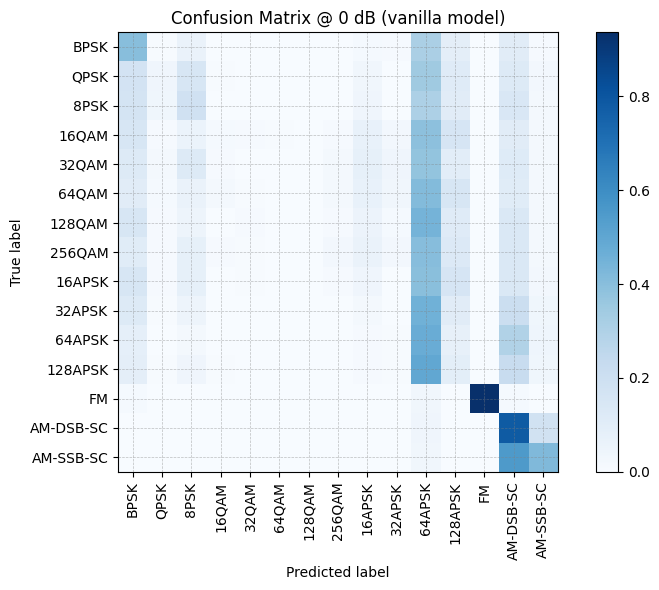

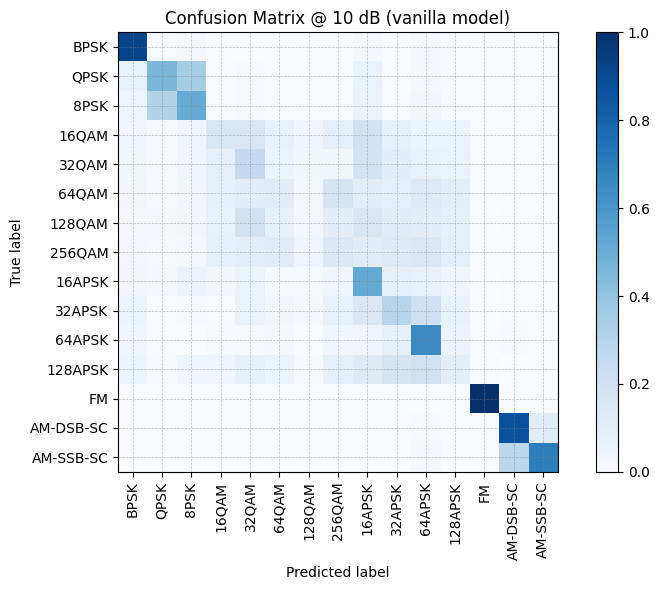

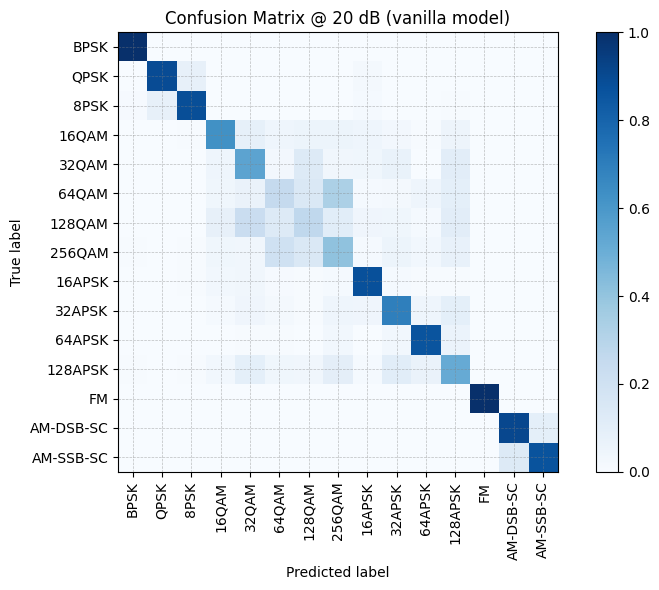

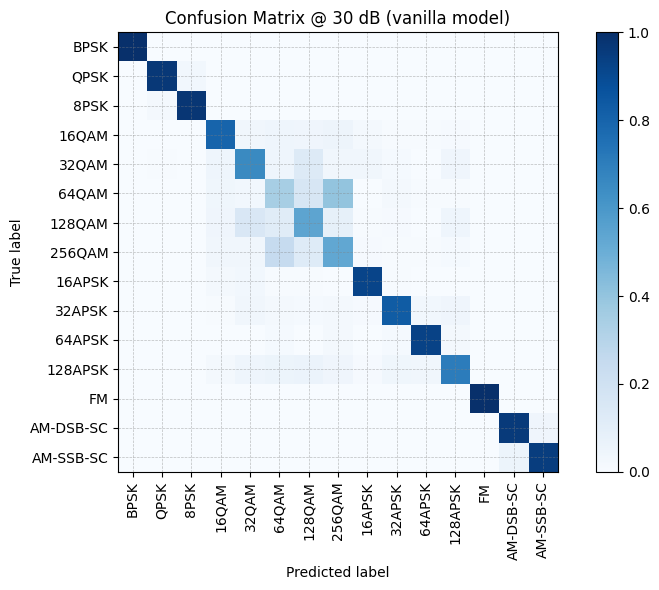

In [18]:
# Plot confusion matrices at 4 different SNRs
snr_to_plot = [0,10,20,30]
plt.figure(figsize=(16,10))
acc = []

# We also want to report accuracy above some SNR
snr_index_lb=3    #13 is the index of +6dB
snr_lb_cor=0
snr_lb_total=0
for snr in dataset.snr_classes:
    # extract classes @ SNR
    indices_snr = (y_snr == snr).nonzero()
    y_exp_i = y_exp[indices_snr]
    y_pred_i = y_pred[indices_snr]
 
    conf = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
    confnorm = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
    for i in range(len(y_exp_i)):
        j = int(y_exp_i[i])
        k = int(np.argmax(y_pred_i[i,:]))
        conf[j,k] = conf[j,k] + 1
    for i in range(0,len(dataset.mod_classes)):
        confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])
 
    # if snr in snr_to_plot:
    #     plot, = np.where(snr_to_plot == snr)[0]
    #     plt.subplot(221+plot)
    #     plot_confusion_matrix(confnorm, labels=dataset.mod_classes, title="Confusion Matrix @ %d dB"%(snr))

    if snr in snr_to_plot:
        plt.figure(figsize=(8, 6))
        plot_confusion_matrix(confnorm, labels=dataset.mod_classes, title=f"Confusion Matrix @ {int(snr)} dB (vanilla model)")
        plt.tight_layout()
        plt.show()

    cor = np.sum(np.diag(conf))
    ncor = np.sum(conf) - cor
    acc.append(cor/(cor+ncor))
    
    if (snr>=snr_index_lb):
        snr_lb_cor+= cor
        snr_lb_total+= cor+ncor

## Accuracy over SNRs

Accuracy @ highest SNR (+30 dB): 0.806520
Accuracy @ >= SNR(6.0 dB): 0.603644196064734
Accuracy overall: 0.558720
SNR [0]: 0.2267318663406683
SNR [2]: 0.2617766911165444
SNR [4]: 0.3002444987775061
SNR [6]: 0.3471882640586797
SNR [8]: 0.3998370008149959
SNR [10]: 0.44841075794621027
SNR [12]: 0.5062754686226569
SNR [14]: 0.5561532192339038
SNR [16]: 0.6264058679706601
SNR [18]: 0.6658516707416463
SNR [20]: 0.7059494702526488
SNR [22]: 0.7401792991035044
SNR [24]: 0.7647921760391198
SNR [26]: 0.784678076609617
SNR [28]: 0.7985330073349634
SNR [30]: 0.806519967400163


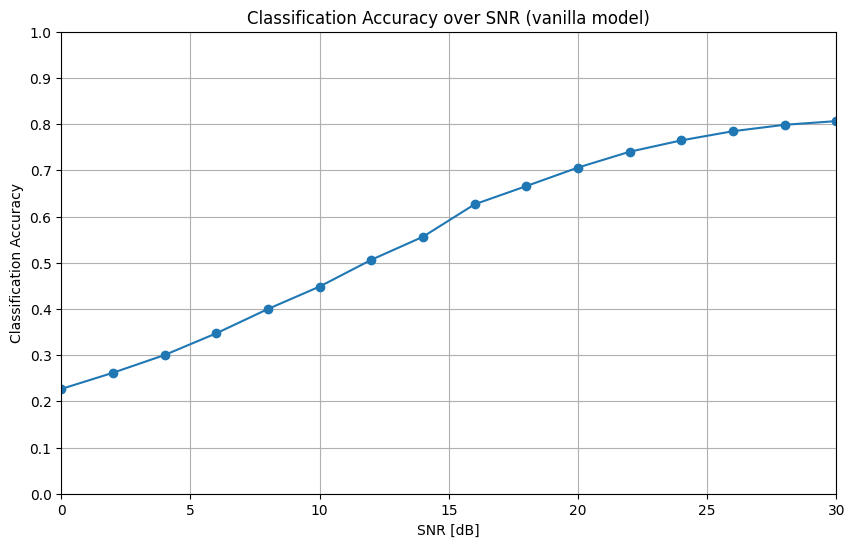

In [19]:
# Plot accuracy over SNR
plt.figure(figsize=(10,6))
plt.plot(dataset.snr_classes, acc, marker='o')
plt.xlabel("SNR [dB]")
plt.xlim([0, 30])
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
title="Classification Accuracy over SNR (vanilla model)"
plt.title(title)
plt.grid()
plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')


print("Accuracy @ highest SNR (+30 dB): %f"%(acc[-1]))
print(f"Accuracy @ >= SNR({dataset.snr_classes[snr_index_lb]} dB): {snr_lb_cor/snr_lb_total}")
print("Accuracy overall: %f"%(np.mean(acc)))
for i, a in enumerate(acc):
    cur = 0 + 2*i
    print(f"SNR [{0 + 2*i}]: {a}")

## Breakdown of the accuracy of each modulations over SNRs

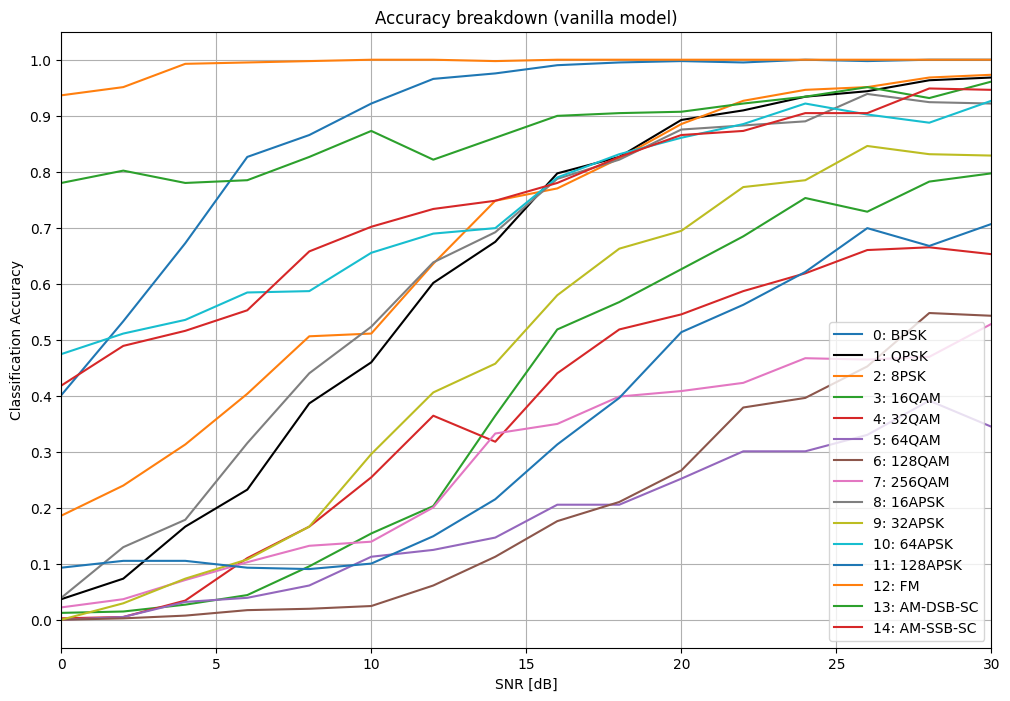

In [20]:
# Plot accuracy per modulation
accs = []
for mod in range(len(dataset.mod_classes)):
    accs.append([])
    for snr in dataset.snr_classes:
        indices = ((y_exp == mod) & (y_snr == snr)).nonzero()
        y_exp_i = y_exp[indices]
        y_pred_i = y_pred[indices]
        cor = np.count_nonzero(y_exp_i == np.argmax(y_pred_i, axis=1))
        accs[mod].append(cor/len(y_exp_i))
        
# Plot accuracy-over-SNR curve
plt.figure(figsize=(12,8))
for mod in range(len(dataset.mod_classes)):
    if accs[mod][-1] < 0.95 or accs[mod][0] > 0.1:
        color = None
    else:
        color = "black"
    plt.plot(dataset.snr_classes, accs[mod], label=str(mod) + ": " + dataset.mod_classes[mod], color=color)
plt.xlabel("SNR [dB]")
plt.xlim([0, 30])
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
title="Accuracy breakdown (vanilla model)"
plt.title(title)
plt.grid()
plt.legend();
plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')